In [2]:
# !pip install pandas numpy matplotlib scipy scikit-learn openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import skew, kurtosis
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [13]:
import os

print("Current folder:")
print(os.getcwd())

print("\nCurrent folder files:")
print(os.listdir())

Current folder:
/Users/mobassherhossainjame/Data_summit_2026_DIU

Current folder files:
['finnova_train.csv', 'data_summit.ipynb', '.ipynb_checkpoints']


In [14]:
import os
import glob

csv_files = glob.glob("**/*.csv", recursive=True)

print("Found CSV files:")

for file in csv_files:
    print(file)

Found CSV files:
finnova_train.csv


In [15]:
import pandas as pd

df = pd.read_csv("finnova_train.csv")

print(df.shape)
display(df.head())

(61835, 31)


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
0,TXN173209,-2.1836,1.8928,-1.1427,-2.4361,1.3969,3.7179,-2.1230,-1.5435,-0.4812,-1.2273,-0.6396,0.4177,-0.1851,1.0918,0.5124,1.3226,-0.6466,0.2248,-0.5394,0.5332,-0.5647,-0.4004,0.3502,0.9932,-0.1392,0.7368,0.1135,0.1488,0.6100,0.0000
1,TXN159667,-1.5469,1.8505,2.1769,3.0357,-1.1929,0.9558,-1.7587,-1.7980,-0.8295,0.0302,-1.4017,-0.6627,-1.5661,0.5526,0.5438,0.2020,0.6370,0.4295,0.8274,0.6960,-1.2864,0.3513,0.0088,0.3204,-0.0748,0.2323,0.0720,0.1345,0.0000,0.0000
2,TXN157896,-1.5227,1.0816,0.1821,0.9902,1.5867,4.4743,-0.9494,1.7100,-0.4479,0.3309,-1.0515,-0.0939,0.0288,-0.1246,-0.3177,1.0037,-0.7182,0.4251,-0.3074,-0.3149,-0.0124,-0.2115,0.0742,0.9865,0.0147,-0.1347,-0.8394,-0.3185,37.0500,0.0000
3,TXN103239,-0.6641,0.4260,2.6913,-1.7009,-0.3761,-0.6739,0.4376,-0.2474,2.5628,-2.0377,0.3758,-2.1475,1.5309,0.9165,-0.0349,-0.3983,0.2574,0.5183,-0.1473,-0.0586,-0.1504,0.0980,-0.3691,0.3365,0.4716,-0.8408,-0.0927,-0.1544,14.5300,0.0000
4,TXN111043,-0.6188,0.6014,1.6764,-0.8583,-0.2046,-0.4588,0.9588,-0.4066,-1.3802,0.4269,-0.1291,0.0680,0.6440,-0.2802,0.1993,-1.5957,-0.3150,0.4182,-2.3621,-0.6015,-0.3975,-0.5935,0.0385,0.3214,-0.4583,-0.8610,-0.2385,-0.0832,65.2700,0.0000


In [16]:
print("Dataset shape:", df.shape)
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

Dataset shape: (61835, 31)
Total rows: 61835
Total columns: 31

Column names:
['Txn_ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25', 'Feature_26', 'Feature_27', 'Feature_28', 'Txn_Value', 'Risk_Flag']

Data types:


,Data Type
Txn_ID,object
Feature_1,float64
Feature_2,float64
Feature_3,float64
Feature_4,float64
Feature_5,float64
Feature_6,float64
Feature_7,float64
Feature_8,float64
Feature_9,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61835 entries, 0 to 61834
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Txn_ID      61835 non-null  object 
 1   Feature_1   61835 non-null  float64
 2   Feature_2   61835 non-null  float64
 3   Feature_3   61835 non-null  float64
 4   Feature_4   61835 non-null  float64
 5   Feature_5   61835 non-null  float64
 6   Feature_6   61835 non-null  float64
 7   Feature_7   61835 non-null  float64
 8   Feature_8   61835 non-null  float64
 9   Feature_9   61835 non-null  float64
 10  Feature_10  61835 non-null  float64
 11  Feature_11  61835 non-null  float64
 12  Feature_12  61835 non-null  float64
 13  Feature_13  61835 non-null  float64
 14  Feature_14  61835 non-null  float64
 15  Feature_15  61835 non-null  float64
 16  Feature_16  61835 non-null  float64
 17  Feature_17  61835 non-null  float64
 18  Feature_18  61835 non-null  float64
 19  Fea

In [17]:
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("Random 5 rows:")
display(df.sample(5, random_state=42))

First 5 rows:


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
0,TXN173209,-2.1836,1.8928,-1.1427,-2.4361,1.3969,3.7179,-2.1230,-1.5435,-0.4812,-1.2273,-0.6396,0.4177,-0.1851,1.0918,0.5124,1.3226,-0.6466,0.2248,-0.5394,0.5332,-0.5647,-0.4004,0.3502,0.9932,-0.1392,0.7368,0.1135,0.1488,0.6100,0.0000
1,TXN159667,-1.5469,1.8505,2.1769,3.0357,-1.1929,0.9558,-1.7587,-1.7980,-0.8295,0.0302,-1.4017,-0.6627,-1.5661,0.5526,0.5438,0.2020,0.6370,0.4295,0.8274,0.6960,-1.2864,0.3513,0.0088,0.3204,-0.0748,0.2323,0.0720,0.1345,0.0000,0.0000
2,TXN157896,-1.5227,1.0816,0.1821,0.9902,1.5867,4.4743,-0.9494,1.7100,-0.4479,0.3309,-1.0515,-0.0939,0.0288,-0.1246,-0.3177,1.0037,-0.7182,0.4251,-0.3074,-0.3149,-0.0124,-0.2115,0.0742,0.9865,0.0147,-0.1347,-0.8394,-0.3185,37.0500,0.0000
3,TXN103239,-0.6641,0.4260,2.6913,-1.7009,-0.3761,-0.6739,0.4376,-0.2474,2.5628,-2.0377,0.3758,-2.1475,1.5309,0.9165,-0.0349,-0.3983,0.2574,0.5183,-0.1473,-0.0586,-0.1504,0.0980,-0.3691,0.3365,0.4716,-0.8408,-0.0927,-0.1544,14.5300,0.0000
4,TXN111043,-0.6188,0.6014,1.6764,-0.8583,-0.2046,-0.4588,0.9588,-0.4066,-1.3802,0.4269,-0.1291,0.0680,0.6440,-0.2802,0.1993,-1.5957,-0.3150,0.4182,-2.3621,-0.6015,-0.3975,-0.5935,0.0385,0.3214,-0.4583,-0.8610,-0.2385,-0.0832,65.2700,0.0000


Last 5 rows:


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
61830,TXN136811,-0.8250,1.0250,0.8476,0.8571,0.0943,-0.2408,0.2892,0.4431,-0.2487,-0.5904,-0.9578,0.2659,-0.3967,0.3391,-0.4155,-0.7226,0.4144,-0.7304,-0.2337,-0.3085,0.1007,0.3149,-0.0661,0.0902,-0.4687,-0.4737,-0.0202,0.0878,14.4500,0.0000
61831,TXN161277,-0.8935,0.2971,1.1716,-2.1886,0.2528,-0.1825,0.4581,-0.0456,-1.6247,0.2412,0.2567,-0.7902,-0.3870,0.0197,-0.4998,1.7606,-0.5567,-0.9201,1.0437,0.0119,-0.2703,-1.0930,-0.2489,-0.9095,0.2978,-0.6840,-0.2505,0.0600,53.9100,0.0000
61832,TXN180879,1.0352,-0.5145,1.0923,-0.5289,-1.4746,-1.0424,-0.3997,-0.1463,1.6127,-1.1722,0.2318,1.5567,1.0537,-0.3345,1.1243,-0.6267,-0.0323,-0.0812,0.3063,0.1134,0.1056,0.4101,-0.0604,0.9681,0.4438,-0.7153,0.0829,0.0550,111.1600,0.0000
61833,TXN104068,1.1192,-1.3424,0.3452,-2.1088,-1.2286,0.1534,-0.9013,0.2340,0.4063,-0.2974,1.5226,1.1275,-0.1764,0.1477,0.8140,-2.5304,0.6278,0.8619,-0.3686,-0.3990,-0.2349,-0.1341,-0.0132,-0.2576,0.2090,0.0371,0.0600,0.0158,116.6700,0.0000
61834,TXN155331,1.3222,-0.3225,0.2293,-0.5229,-0.9421,-1.4211,0.0130,-0.3930,-1.2550,0.6366,0.0273,0.4551,0.9920,0.1470,0.6022,-1.5136,0.1348,0.1460,-0.6224,-0.3791,-0.7499,-1.8045,0.3001,0.7062,-0.0438,0.5960,-0.0778,0.0218,54.7500,0.0000


Random 5 rows:


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
12004,TXN146398,1.1630,-1.6091,0.7535,-1.2473,-2.0811,-0.5665,-1.2057,-0.0268,-1.7989,1.5486,1.2829,-0.4081,-0.0041,-0.1565,0.2053,0.0291,0.2128,0.8226,-0.2689,-0.0493,0.0807,0.2746,-0.1090,0.5253,0.2159,-0.1420,0.0162,0.0418,205.9300,0.0000
31407,TXN142189,1.2043,0.1091,0.6007,0.5679,-0.6414,-0.8154,-0.1106,0.0093,-0.0731,0.1414,1.4894,0.5391,-0.9224,0.6655,0.4439,0.5168,-0.5267,0.0116,0.1017,-0.1733,-0.1964,-0.6779,0.1568,0.5033,0.1205,0.0636,-0.0373,0.0083,3.3000,0.0000
6145,TXN179089,-2.3911,-1.4328,1.6005,-2.4353,-0.9957,-0.4256,-0.1481,-0.1608,-1.4507,2.1895,0.7579,-1.1705,-0.3206,-0.8448,-0.0914,0.2550,-0.3734,1.0173,-0.5609,-0.0757,-0.3120,0.2275,-0.2768,-0.0276,0.5136,-0.2477,-0.2000,-0.2594,172.3700,0.0000
20333,TXN139447,1.0946,0.1041,0.3448,1.4241,-0.1664,-0.1707,0.1227,-0.0363,0.2868,-0.1604,-0.5153,0.6108,0.0368,0.0498,-0.1133,-0.7315,0.2533,-0.9888,-0.3734,-0.0850,-0.0736,-0.0568,-0.1036,0.0994,0.6571,-0.3194,0.0349,0.0200,63.5000,0.0000
57707,TXN119486,0.9358,-0.4504,1.1048,1.1846,-0.3272,1.7937,-0.9653,0.7695,1.1218,-0.3612,-0.1181,0.0007,-1.6491,0.0892,1.4591,-1.1132,1.0514,-1.8028,-1.7506,-0.3232,0.0480,0.3874,0.1246,-0.9936,0.0367,-0.2798,0.1232,0.0224,43.8700,0.0000


In [18]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_report = missing_report.sort_values(
    by="Missing_Count",
    ascending=False
)

display(missing_report)

print("Total missing cells:", df.isnull().sum().sum())

,Missing_Count,Missing_Percentage
Txn_ID,0,0.0000
Feature_16,0,0.0000
Txn_Value,0,0.0000
Feature_28,0,0.0000
Feature_27,0,0.0000
Feature_26,0,0.0000
Feature_25,0,0.0000
Feature_24,0,0.0000
Feature_23,0,0.0000
Feature_22,0,0.0000


Total missing cells: 0


In [19]:
duplicate_rows = df.duplicated().sum()

print("Duplicate full rows:", duplicate_rows)

if "Txn_ID" in df.columns:
    duplicate_txn_id = df["Txn_ID"].duplicated().sum()
    unique_txn_id = df["Txn_ID"].nunique()

    print("Unique Txn_ID:", unique_txn_id)
    print("Duplicate Txn_ID:", duplicate_txn_id)

Duplicate full rows: 0
Unique Txn_ID: 61835
Duplicate Txn_ID: 0


In [20]:
if "Txn_ID" in df.columns:

    valid_pattern = df["Txn_ID"].astype(str).str.match(
        r"^TXN\d+$",
        na=False
    )

    print("Correct TXN pattern:", valid_pattern.sum())
    print("Incorrect TXN pattern:", (~valid_pattern).sum())

    if (~valid_pattern).sum() > 0:
        display(df.loc[~valid_pattern, ["Txn_ID"]].head(20))

Correct TXN pattern: 61835
Incorrect TXN pattern: 0


In [22]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
non_numeric_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print(numeric_columns)

print("\nNon-numeric columns:", len(non_numeric_columns))
print(non_numeric_columns)


target_column = "Risk_Flag"
id_column = "Txn_ID"

feature_columns = [
    col for col in numeric_columns
    if col not in [target_column, id_column]
]

print("Total model features:", len(feature_columns))
print(feature_columns)

Numeric columns: 30
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25', 'Feature_26', 'Feature_27', 'Feature_28', 'Txn_Value', 'Risk_Flag']

Non-numeric columns: 1
['Txn_ID']
Total model features: 29
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25', 'Feature_26', 'Feature_27', 'Feature_28', 'Txn_Value']


In [23]:
unique_report = pd.DataFrame({
    "Feature": df.columns,
    "Unique_Count": [df[col].nunique(dropna=False) for col in df.columns],
    "Data_Type": [df[col].dtype for col in df.columns]
})

unique_report = unique_report.sort_values(
    by="Unique_Count",
    ascending=True
)

display(unique_report)

,Feature,Unique_Count,Data_Type
30,Risk_Flag,2,float64
29,Txn_Value,19838,float64
28,Feature_28,61835,float64
27,Feature_27,61835,float64
26,Feature_26,61835,float64
25,Feature_25,61835,float64
24,Feature_24,61835,float64
23,Feature_23,61835,float64
22,Feature_22,61835,float64
21,Feature_21,61835,float64


In [29]:
for column in df.columns:

    print("=" * 70)
    print(f"Feature: {column}")
    print(f"Unique values: {df[column].nunique(dropna=False)}")

    display(
        df[column]
        .value_counts(dropna=False)
        .head(10)
        .to_frame("Count")
    )

    print("less unique value")
for column in df.columns:

    if df[column].nunique(dropna=False) <= 20:

        print(f"\nValue counts of {column}")

        value_count_table = pd.DataFrame({
            "Count": df[column].value_counts(dropna=False),
            "Percentage": (
                df[column].value_counts(
                    dropna=False,
                    normalize=True
                ) * 100
            )
        })

        display(value_count_table)
    

Feature: Txn_ID
Unique values: 61835


,Count
Txn_ID,
TXN173209,1
TXN163866,1
TXN124193,1
TXN181426,1
TXN125721,1
TXN103352,1
TXN179460,1
TXN166194,1
TXN130514,1


less unique value
Feature: Feature_1
Unique values: 61835


,Count
Feature_1,
-2.1836,1
-3.7580,1
-0.1993,1
1.2804,1
1.1504,1
1.2549,1
-1.5983,1
-1.5351,1
-0.6784,1


less unique value
Feature: Feature_2
Unique values: 61835


...

,Count
Txn_Value,
0.0000,3077
0.9800,36
2.9200,34
1.1100,33
3.0300,33
1.9600,33
0.9200,33
3.2300,32
1.4200,32


less unique value
Feature: Risk_Flag
Unique values: 2


,Count
Risk_Flag,
0.0000,61708
1.0000,127


less unique value

Value counts of Risk_Flag


,Count,Percentage
Risk_Flag,,
0.0000,61708,99.7946
1.0000,127,0.2054


In [31]:
statistical_summary = df[numeric_columns].describe().T

statistical_summary["Range"] = (
    statistical_summary["max"] -
    statistical_summary["min"]
)

statistical_summary["Missing"] = (
    df[numeric_columns].isnull().sum()
)

statistical_summary["Unique"] = (
    df[numeric_columns].nunique()
)

display(statistical_summary)

print("more percentile")
extended_summary = df[numeric_columns].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).T

display(extended_summary)

,count,mean,std,min,25%,50%,75%,max,Range,Missing,Unique
Feature_1,"61,835.0000",-0.2449,1.8219,-56.3987,-1.0222,-0.2533,1.1575,1.6911,58.0898,0,61835
Feature_2,"61,835.0000",0.0026,1.6052,-72.7128,-0.5779,0.0913,0.7578,16.1675,88.8803,0,61835
Feature_3,"61,835.0000",0.6735,1.2655,-30.0043,0.1749,0.7472,1.3650,9.3827,39.3870,0,61835
Feature_4,"61,835.0000",0.1473,1.3346,-5.1788,-0.7122,0.1747,1.0099,16.7078,21.8866,0,61835
Feature_5,"61,835.0000",-0.2843,1.3128,-42.1543,-0.9019,-0.3186,0.2378,34.8110,76.9652,0,61835
Feature_6,"61,835.0000",0.0885,1.2887,-26.1600,-0.6559,-0.1648,0.4732,22.5170,48.6770,0,61835
Feature_7,"61,835.0000",-0.1182,1.1690,-26.5513,-0.6055,-0.0689,0.4079,36.6818,63.2331,0,61835
Feature_8,"61,835.0000",0.0555,1.2319,-41.4766,-0.1357,0.0771,0.3695,19.1655,60.6421,0,61835
Feature_9,"61,835.0000",-0.0788,1.1006,-8.7507,-0.7058,-0.1403,0.5068,15.5963,24.3469,0,61835
Feature_10,"61,835.0000",-0.0136,1.0611,-18.2690,-0.4845,-0.0917,0.4359,23.7433,42.0124,0,61835


more percentile


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Feature_1,"61,835.0000",-0.2449,1.8219,-56.3987,-6.6289,-2.9964,-1.9955,-1.0222,-0.2533,1.1575,1.2763,1.3474,1.4853,1.6911
Feature_2,"61,835.0000",0.0026,1.6052,-72.7128,-5.1625,-1.9632,-1.2922,-0.5779,0.0913,0.7578,1.2883,1.7539,3.7733,16.1675
Feature_3,"61,835.0000",0.6735,1.2655,-30.0043,-3.3016,-1.1166,-0.4606,0.1749,0.7472,1.3650,1.9210,2.2886,2.8724,9.3827
Feature_4,"61,835.0000",0.1473,1.3346,-5.1788,-2.9142,-2.0071,-1.5529,-0.7122,0.1747,1.0099,1.6023,2.4407,3.2938,16.7078
Feature_5,"61,835.0000",-0.2843,1.3128,-42.1543,-3.3994,-1.8578,-1.4782,-0.9019,-0.3186,0.2378,0.9920,1.7945,2.9610,34.8110
Feature_6,"61,835.0000",0.0885,1.2887,-26.1600,-2.0659,-1.2662,-1.0461,-0.6559,-0.1648,0.4732,1.5009,3.1969,4.1846,22.5170
Feature_7,"61,835.0000",-0.1182,1.1690,-26.5513,-3.1824,-1.4306,-1.0913,-0.6055,-0.0689,0.4079,0.8224,1.1368,2.4352,36.6818
Feature_8,"61,835.0000",0.0555,1.2319,-41.4766,-4.0239,-0.7615,-0.3553,-0.1357,0.0771,0.3695,0.7934,1.0644,2.1710,19.1655
Feature_9,"61,835.0000",-0.0788,1.1006,-8.7507,-2.4962,-1.8376,-1.3457,-0.7058,-0.1403,0.5068,1.2077,1.7320,3.0418,15.5963
Feature_10,"61,835.0000",-0.0136,1.0611,-18.2690,-2.1476,-1.3340,-0.9627,-0.4845,-0.0917,0.4359,0.9182,1.4402,3.0763,23.7433


In [34]:
import pandas as pd
from scipy.stats import skew, kurtosis


def classify_skewness(skew_value):

    absolute_skew = abs(skew_value)

    if absolute_skew < 0.5:
        return "Approximately Symmetric"

    elif absolute_skew < 1:
        return "Moderately Skewed"

    else:
        return "Highly Skewed"



skewness_report = []

for column in feature_columns:

    column_data = df[column].dropna()

    skew_value = skew(
        column_data,
        bias=False
    )

    kurtosis_value = kurtosis(
        column_data,
        fisher=True,
        bias=False
    )

    if skew_value > 0:
        direction = "Right Skewed"

    elif skew_value < 0:
        direction = "Left Skewed"

    else:
        direction = "Symmetric"

    skewness_report.append({
        "Feature": column,
        "Skewness": skew_value,
        "Absolute_Skewness": abs(skew_value),
        "Direction": direction,
        "Skew_Class": classify_skewness(skew_value),
        "Excess_Kurtosis": kurtosis_value
    })


skewness_df = pd.DataFrame(skewness_report)

skewness_df = skewness_df.sort_values(
    by="Absolute_Skewness",
    ascending=False
).reset_index(drop=True)

display(skewness_df)

,Feature,Skewness,Absolute_Skewness,Direction,Skew_Class,Excess_Kurtosis
0,Txn_Value,15.5128,15.5128,Right Skewed,Highly Skewed,726.8773
1,Feature_28,14.9451,14.9451,Right Skewed,Highly Skewed,"1,800.6260"
2,Feature_23,-9.0333,9.0333,Left Skewed,Highly Skewed,635.4495
3,Feature_8,-8.1065,8.1065,Left Skewed,Highly Skewed,174.8875
4,Feature_21,5.2457,5.2457,Right Skewed,Highly Skewed,236.9917
5,Feature_27,-5.1569,5.1569,Left Skewed,Highly Skewed,236.5082
6,Feature_2,-5.1508,5.1508,Left Skewed,Highly Skewed,144.7393
7,Feature_17,-5.1118,5.1118,Left Skewed,Highly Skewed,114.7639
8,Feature_3,-4.4361,4.4361,Left Skewed,Highly Skewed,61.0103
9,Feature_1,-3.7414,3.7414,Left Skewed,Highly Skewed,41.1523


In [35]:
skew_category_count = (
    skewness_df["Skew_Class"]
    .value_counts()
    .to_frame("Feature_Count")
)

display(skew_category_count)

,Feature_Count
Skew_Class,
Highly Skewed,16
Moderately Skewed,7
Approximately Symmetric,6


In [36]:
highly_skewed_features = skewness_df[
    skewness_df["Absolute_Skewness"] >= 1
]

display(highly_skewed_features)

,Feature,Skewness,Absolute_Skewness,Direction,Skew_Class,Excess_Kurtosis
0,Txn_Value,15.5128,15.5128,Right Skewed,Highly Skewed,726.8773
1,Feature_28,14.9451,14.9451,Right Skewed,Highly Skewed,"1,800.6260"
2,Feature_23,-9.0333,9.0333,Left Skewed,Highly Skewed,635.4495
3,Feature_8,-8.1065,8.1065,Left Skewed,Highly Skewed,174.8875
4,Feature_21,5.2457,5.2457,Right Skewed,Highly Skewed,236.9917
5,Feature_27,-5.1569,5.1569,Left Skewed,Highly Skewed,236.5082
6,Feature_2,-5.1508,5.1508,Left Skewed,Highly Skewed,144.7393
7,Feature_17,-5.1118,5.1118,Left Skewed,Highly Skewed,114.7639
8,Feature_3,-4.4361,4.4361,Left Skewed,Highly Skewed,61.0103
9,Feature_1,-3.7414,3.7414,Left Skewed,Highly Skewed,41.1523


In [37]:
def calculate_iqr_outliers(data, column):

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    outlier_mask = (
        (data[column] < lower_fence) |
        (data[column] > upper_fence)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (
        outlier_count / len(data)
    ) * 100

    return {
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Fence": lower_fence,
        "Upper_Fence": upper_fence,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage,
        "Minimum": data[column].min(),
        "Maximum": data[column].max()
    }

In [38]:
outlier_report = []

for column in feature_columns:

    result = calculate_iqr_outliers(
        df,
        column
    )

    outlier_report.append(result)

outlier_df = pd.DataFrame(outlier_report)

outlier_df = outlier_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

display(outlier_df)

,Feature,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percentage,Minimum,Maximum
27,Feature_28,-0.0048,0.0764,0.0811,-0.1265,0.1981,11357,18.3666,-11.7159,33.8426
26,Feature_27,-0.0602,0.0848,0.1451,-0.2778,0.3024,9193,14.8670,-22.5673,11.1348
28,Txn_Value,8.6300,106.9900,98.3600,-138.9100,254.5300,6874,11.1167,0.0000,"25,361.2100"
19,Feature_20,-0.1698,0.1664,0.3362,-0.6741,0.6708,6334,10.2434,-18.2667,39.4108
7,Feature_8,-0.1357,0.3695,0.5052,-0.8936,1.1274,5421,8.7669,-41.4766,19.1655
22,Feature_23,-0.1740,0.0818,0.2558,-0.5577,0.4655,5061,8.1847,-44.8102,18.9987
5,Feature_6,-0.6559,0.4732,1.1291,-2.3495,2.1668,5017,8.1135,-26.1600,22.5170
20,Feature_21,-0.2257,0.1170,0.3427,-0.7397,0.6310,3966,6.4138,-20.2660,27.2051
4,Feature_5,-0.9019,0.2378,1.1397,-2.6115,1.9475,3782,6.1163,-42.1543,34.8110
11,Feature_12,-0.4047,0.6438,1.0486,-1.9776,2.2167,3542,5.7281,-17.7854,4.8655


In [39]:
features_with_outliers = outlier_df[
    outlier_df["Outlier_Count"] > 0
]

display(features_with_outliers)

,Feature,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percentage,Minimum,Maximum
27,Feature_28,-0.0048,0.0764,0.0811,-0.1265,0.1981,11357,18.3666,-11.7159,33.8426
26,Feature_27,-0.0602,0.0848,0.1451,-0.2778,0.3024,9193,14.8670,-22.5673,11.1348
28,Txn_Value,8.6300,106.9900,98.3600,-138.9100,254.5300,6874,11.1167,0.0000,"25,361.2100"
19,Feature_20,-0.1698,0.1664,0.3362,-0.6741,0.6708,6334,10.2434,-18.2667,39.4108
7,Feature_8,-0.1357,0.3695,0.5052,-0.8936,1.1274,5421,8.7669,-41.4766,19.1655
22,Feature_23,-0.1740,0.0818,0.2558,-0.5577,0.4655,5061,8.1847,-44.8102,18.9987
5,Feature_6,-0.6559,0.4732,1.1291,-2.3495,2.1668,5017,8.1135,-26.1600,22.5170
20,Feature_21,-0.2257,0.1170,0.3427,-0.7397,0.6310,3966,6.4138,-20.2660,27.2051
4,Feature_5,-0.9019,0.2378,1.1397,-2.6115,1.9475,3782,6.1163,-42.1543,34.8110
11,Feature_12,-0.4047,0.6438,1.0486,-1.9776,2.2167,3542,5.7281,-17.7854,4.8655


In [40]:
column_name = "Txn_Value"

q1 = df[column_name].quantile(0.25)
q3 = df[column_name].quantile(0.75)

iqr = q3 - q1

lower_fence = q1 - (1.5 * iqr)
upper_fence = q3 + (1.5 * iqr)

outlier_rows = df[
    (df[column_name] < lower_fence) |
    (df[column_name] > upper_fence)
]

print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Total outlier rows:", len(outlier_rows))

display(
    outlier_rows.sort_values(
        by=column_name,
        ascending=False
    ).head(20)
)

Lower fence: -138.91000000000003
Upper fence: 254.53000000000003
Total outlier rows: 6874


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
55792,TXN162233,-36.7931,-63.3739,-20.6623,16.7078,-20.6616,7.7129,24.9575,-4.7136,-2.6924,-8.4135,1.1996,1.8826,3.4994,4.0832,1.4055,0.7773,0.9120,5.0388,-7.2117,39.4108,11.4535,-10.9223,-17.1760,1.1777,-7.0213,-2.5284,-3.6064,3.4486,"25,361.2100",0.0000
14460,TXN169984,-23.3877,-18.1005,-20.2035,4.2554,-42.1543,22.5170,36.6818,-4.8549,1.6519,-7.7961,-0.0606,-0.0364,3.0268,-0.5076,2.0362,6.0885,-0.2044,-1.0298,0.2255,-13.6966,-5.8990,-0.1413,-6.0814,1.9289,0.6679,0.4465,11.1348,-9.6181,"9,588.5800",0.0000
10410,TXN180037,-14.7107,-23.2399,-7.6343,5.9813,-15.6266,8.0685,21.2419,-1.8953,-1.4492,-6.2866,-1.3619,-1.4413,0.6183,0.2345,-0.4954,1.2373,-0.8704,2.7387,-2.2576,16.1815,4.4181,-0.4856,17.2952,-0.5047,1.9426,-1.0485,-2.4611,0.6247,"8,967.7600",0.0000
42966,TXN142960,-11.9809,-15.6672,-2.6950,3.4361,4.7029,-5.7415,-9.4554,-5.7142,4.1201,0.0806,-0.0740,2.1852,-1.4617,1.7883,2.8056,1.1321,0.4942,-1.4156,-1.8557,-0.9377,-1.3308,-5.9473,-44.8102,3.1213,-10.2923,-1.6543,5.0082,-0.1499,"7,747.2700",0.0000
49838,TXN100372,-9.4639,-18.7890,-7.8795,2.8971,-3.9172,5.2081,6.6607,-0.7873,-1.5706,-2.0107,-0.1900,-0.4118,1.0154,1.2197,0.6624,1.5976,0.2857,-0.0734,-0.6312,11.7131,3.5365,-2.8123,-5.1977,1.3454,-1.1299,-0.6589,-1.0769,0.9856,"7,330.7300",0.0000
6044,TXN121049,-3.4791,-3.3441,-6.6657,0.7521,-25.8167,16.2537,25.2228,-4.3621,-0.7602,-4.3881,1.9154,-1.4753,-0.2938,-1.2591,0.1169,2.2344,-0.8619,-0.0993,0.0175,-2.6356,-1.6185,0.2842,1.3485,0.6539,-0.0243,1.0084,3.1968,-2.1581,"7,299.3300",0.0000
28044,TXN105231,-8.8620,-15.0737,-5.6361,4.1679,-15.7304,9.8720,17.3970,-1.0941,-2.1874,-4.2069,-0.3469,-0.9863,-0.0530,-0.0813,-1.7187,-1.5780,0.5361,3.4639,-0.5480,11.1814,2.7478,-0.5829,12.8038,-0.9951,0.8116,-0.6520,-1.4775,0.6416,"6,890.4600",0.0000
47895,TXN126311,-4.7632,-5.2712,-7.0673,4.3328,-20.3899,13.0489,23.2159,-3.8698,-3.2895,-2.7907,1.4215,-2.0460,0.2767,0.2266,1.1121,1.9403,-1.1447,1.2905,0.7175,1.3147,-0.1684,0.4952,3.9595,0.1081,0.6024,0.2885,1.9018,-1.2795,"6,858.7500",0.0000
12491,TXN182182,-19.0217,-21.2736,-9.3145,6.7423,-14.5677,9.7556,21.9370,-5.1301,-0.1356,-2.1002,3.1591,-0.3499,2.6212,-1.5896,2.6321,2.4222,-1.3279,-0.5931,1.6113,-8.7421,-3.9689,1.8887,8.6716,0.2887,3.4734,0.4638,3.9369,-0.1452,"6,843.8100",0.0000
47711,TXN158611,-8.6266,-17.7939,-5.8180,3.0114,-6.4042,1.2968,6.1466,-1.4832,-2.2865,-1.0568,-0.5809,-0.9964,0.2472,1.0649,0.6142,-0.5391,1.3631,0.4132,-1.9798,10.2333,2.9817,-2.8175,-4.6725,0.3353,-1.3559,-0.5915,-0.9685,0.9140,"6,785.5800",0.0000


In [41]:
target_count = df["Risk_Flag"].value_counts().sort_index()

target_percentage = (
    df["Risk_Flag"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_report = pd.DataFrame({
    "Count": target_count,
    "Percentage": target_percentage
})

display(target_report)

,Count,Percentage
Risk_Flag,,
0.0000,61708,99.7946
1.0000,127,0.2054


In [42]:
normal_count = (df["Risk_Flag"] == 0).sum()
risk_count = (df["Risk_Flag"] == 1).sum()

print("Normal transactions:", normal_count)
print("Risky transactions:", risk_count)

if risk_count > 0:

    imbalance_ratio = normal_count / risk_count

    print(
        f"Class imbalance ratio: "
        f"{imbalance_ratio:.2f} : 1"
    )

Normal transactions: 61708
Risky transactions: 127
Class imbalance ratio: 485.89 : 1


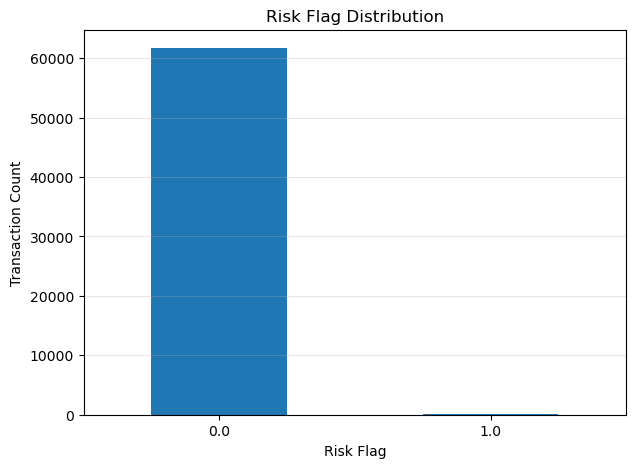

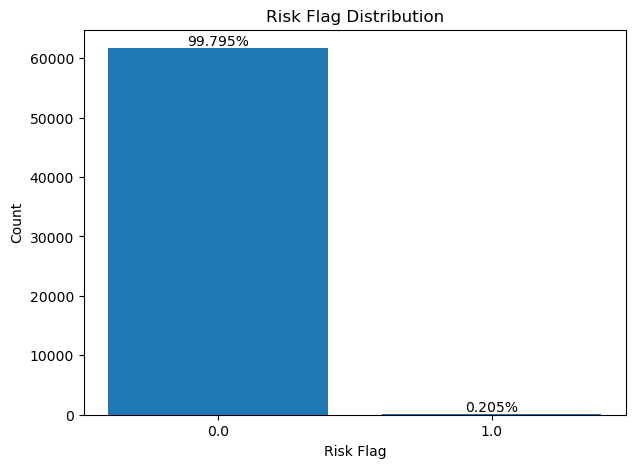

In [44]:
target_count.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Risk Flag Distribution")
plt.xlabel("Risk Flag")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_report.index.astype(str),
    target_report["Count"]
)

plt.title("Risk Flag Distribution")
plt.xlabel("Risk Flag")
plt.ylabel("Count")

for bar, percentage in zip(
    bars,
    target_report["Percentage"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.3f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [45]:
txn_value_report = pd.Series({
    "Count": df["Txn_Value"].count(),
    "Missing": df["Txn_Value"].isnull().sum(),
    "Unique": df["Txn_Value"].nunique(),
    "Mean": df["Txn_Value"].mean(),
    "Median": df["Txn_Value"].median(),
    "Standard_Deviation": df["Txn_Value"].std(),
    "Minimum": df["Txn_Value"].min(),
    "Q1": df["Txn_Value"].quantile(0.25),
    "Q3": df["Txn_Value"].quantile(0.75),
    "Maximum": df["Txn_Value"].max(),
    "Skewness": df["Txn_Value"].skew(),
    "Zero_Count": (df["Txn_Value"] == 0).sum(),
    "Zero_Percentage": (
        (df["Txn_Value"] == 0).mean() * 100
    )
})

display(txn_value_report.to_frame("Value"))

,Value
Count,"61,835.0000"
Missing,0.0000
Unique,"19,838.0000"
Mean,119.2565
Median,31.7200
Standard_Deviation,320.9112
Minimum,0.0000
Q1,8.6300
Q3,106.9900
Maximum,"25,361.2100"


In [46]:
txn_percentiles = df["Txn_Value"].quantile([
    0.00,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999,
    1.00
])

display(txn_percentiles.to_frame("Txn_Value"))

,Txn_Value
0.0000,0.0000
0.2500,8.6300
0.5000,31.7200
0.7500,106.9900
0.9000,278.0660
0.9500,488.6290
0.9900,"1,369.0676"
0.9950,"1,954.2419"
0.9990,"3,752.9505"
1.0000,"25,361.2100"


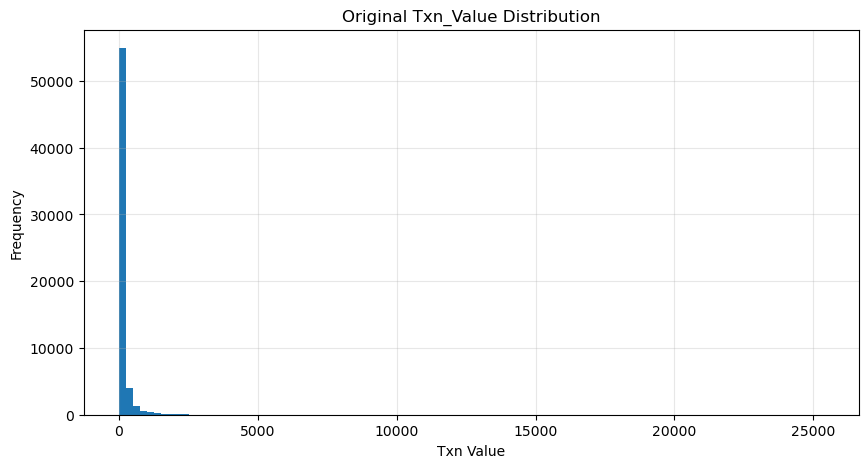

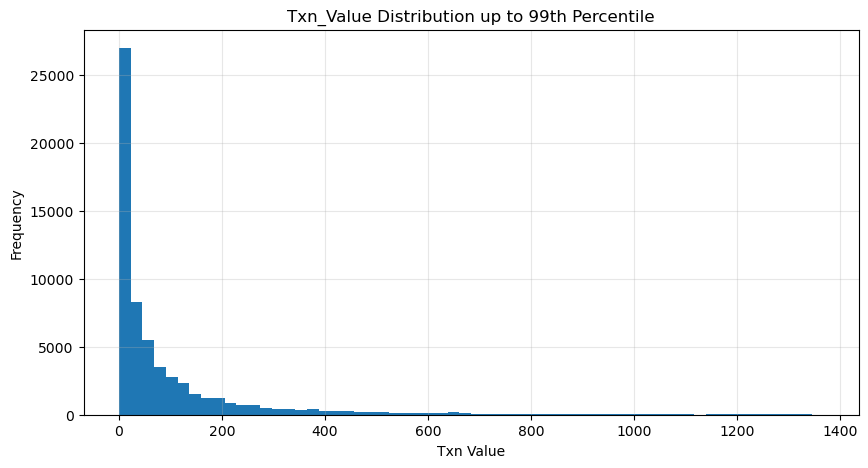

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Txn_Value"].dropna(),
    bins=100
)

plt.title("Original Txn_Value Distribution")
plt.xlabel("Txn Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


txn_99_percentile = df["Txn_Value"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[
        df["Txn_Value"] <= txn_99_percentile,
        "Txn_Value"
    ],
    bins=60
)

plt.title("Txn_Value Distribution up to 99th Percentile")
plt.xlabel("Txn Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

Original skewness: 15.512789355347314
Log transformed skewness: -0.06787155402776948


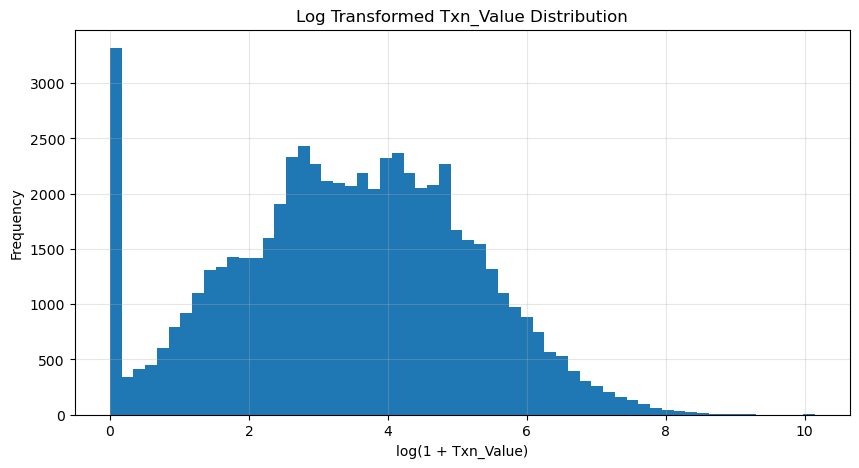

In [50]:
df["Txn_Value_log"] = np.log1p(
    df["Txn_Value"]
)

print(
    "Original skewness:",
    df["Txn_Value"].skew()
)

print(
    "Log transformed skewness:",
    df["Txn_Value_log"].skew()
)


plt.figure(figsize=(10, 5))

plt.hist(
    df["Txn_Value_log"],
    bins=60
)

plt.title("Log Transformed Txn_Value Distribution")
plt.xlabel("log(1 + Txn_Value)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

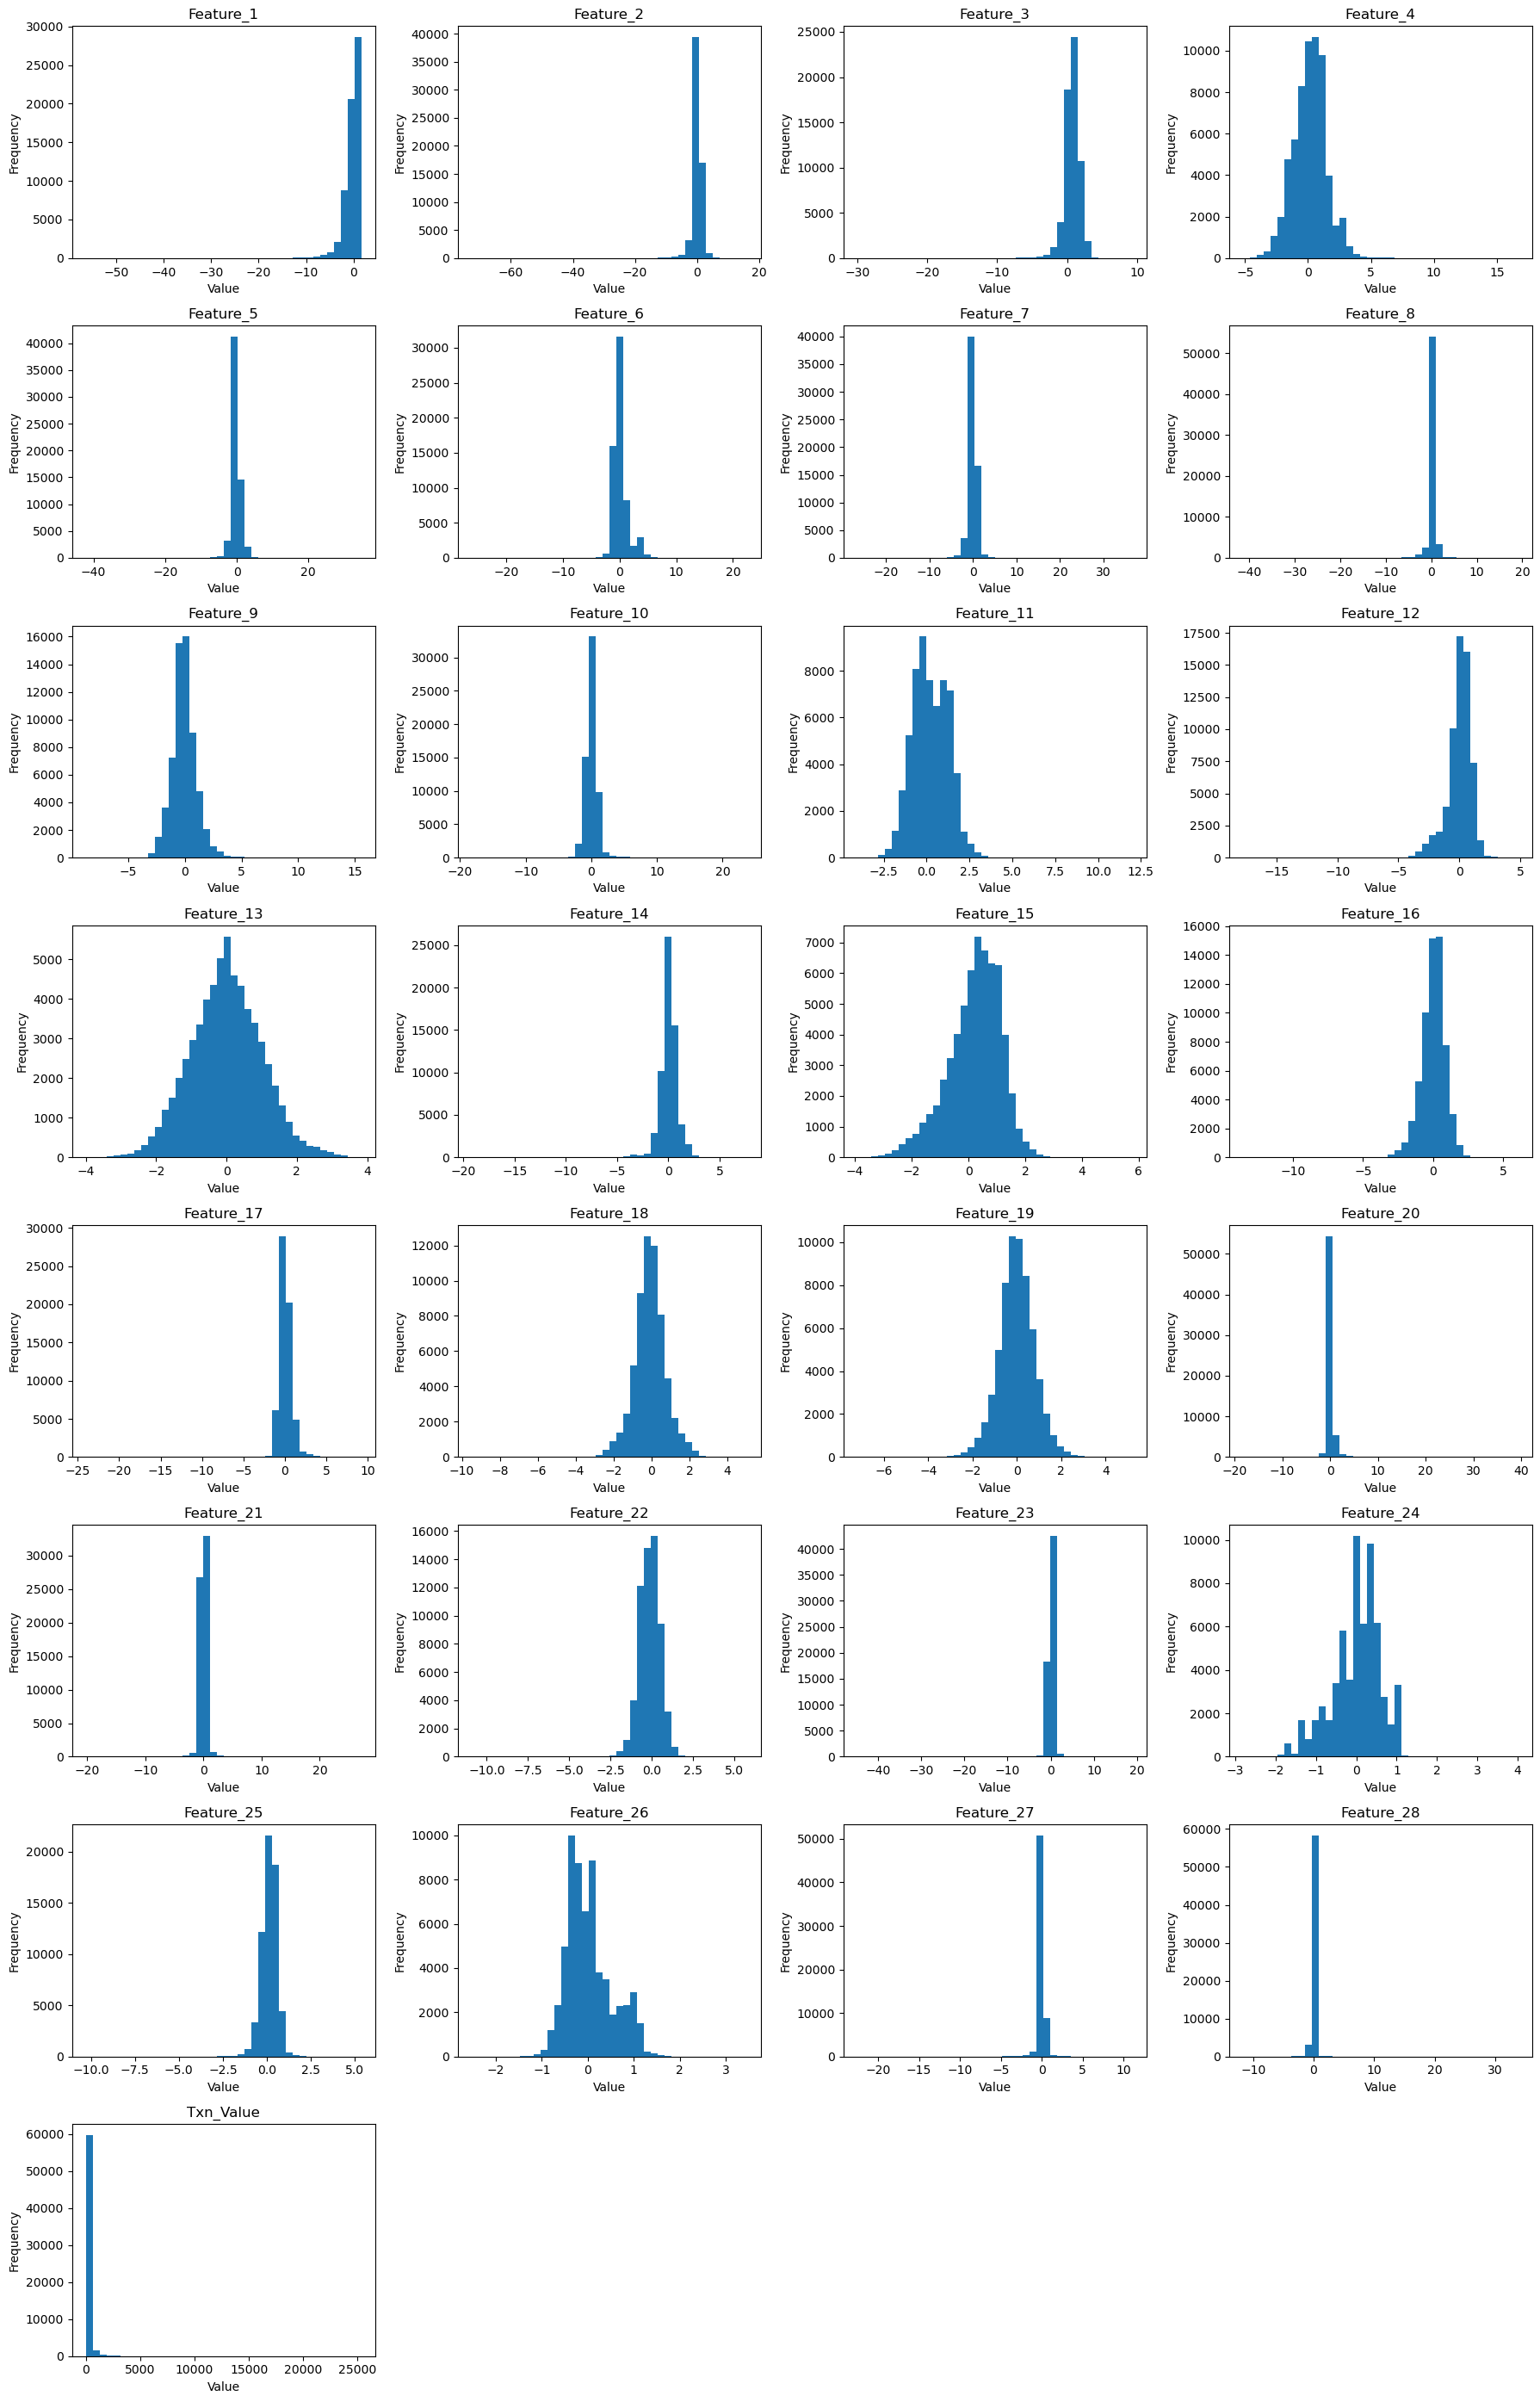

In [51]:
plot_columns = feature_columns.copy()

number_of_columns = 4
number_of_rows = int(
    np.ceil(len(plot_columns) / number_of_columns)
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, number_of_rows * 3.5)
)

axes = axes.flatten()

for index, column in enumerate(plot_columns):

    axes[index].hist(
        df[column].dropna(),
        bins=40
    )

    axes[index].set_title(column)
    axes[index].set_xlabel("Value")
    axes[index].set_ylabel("Frequency")

for index in range(
    len(plot_columns),
    len(axes)
):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

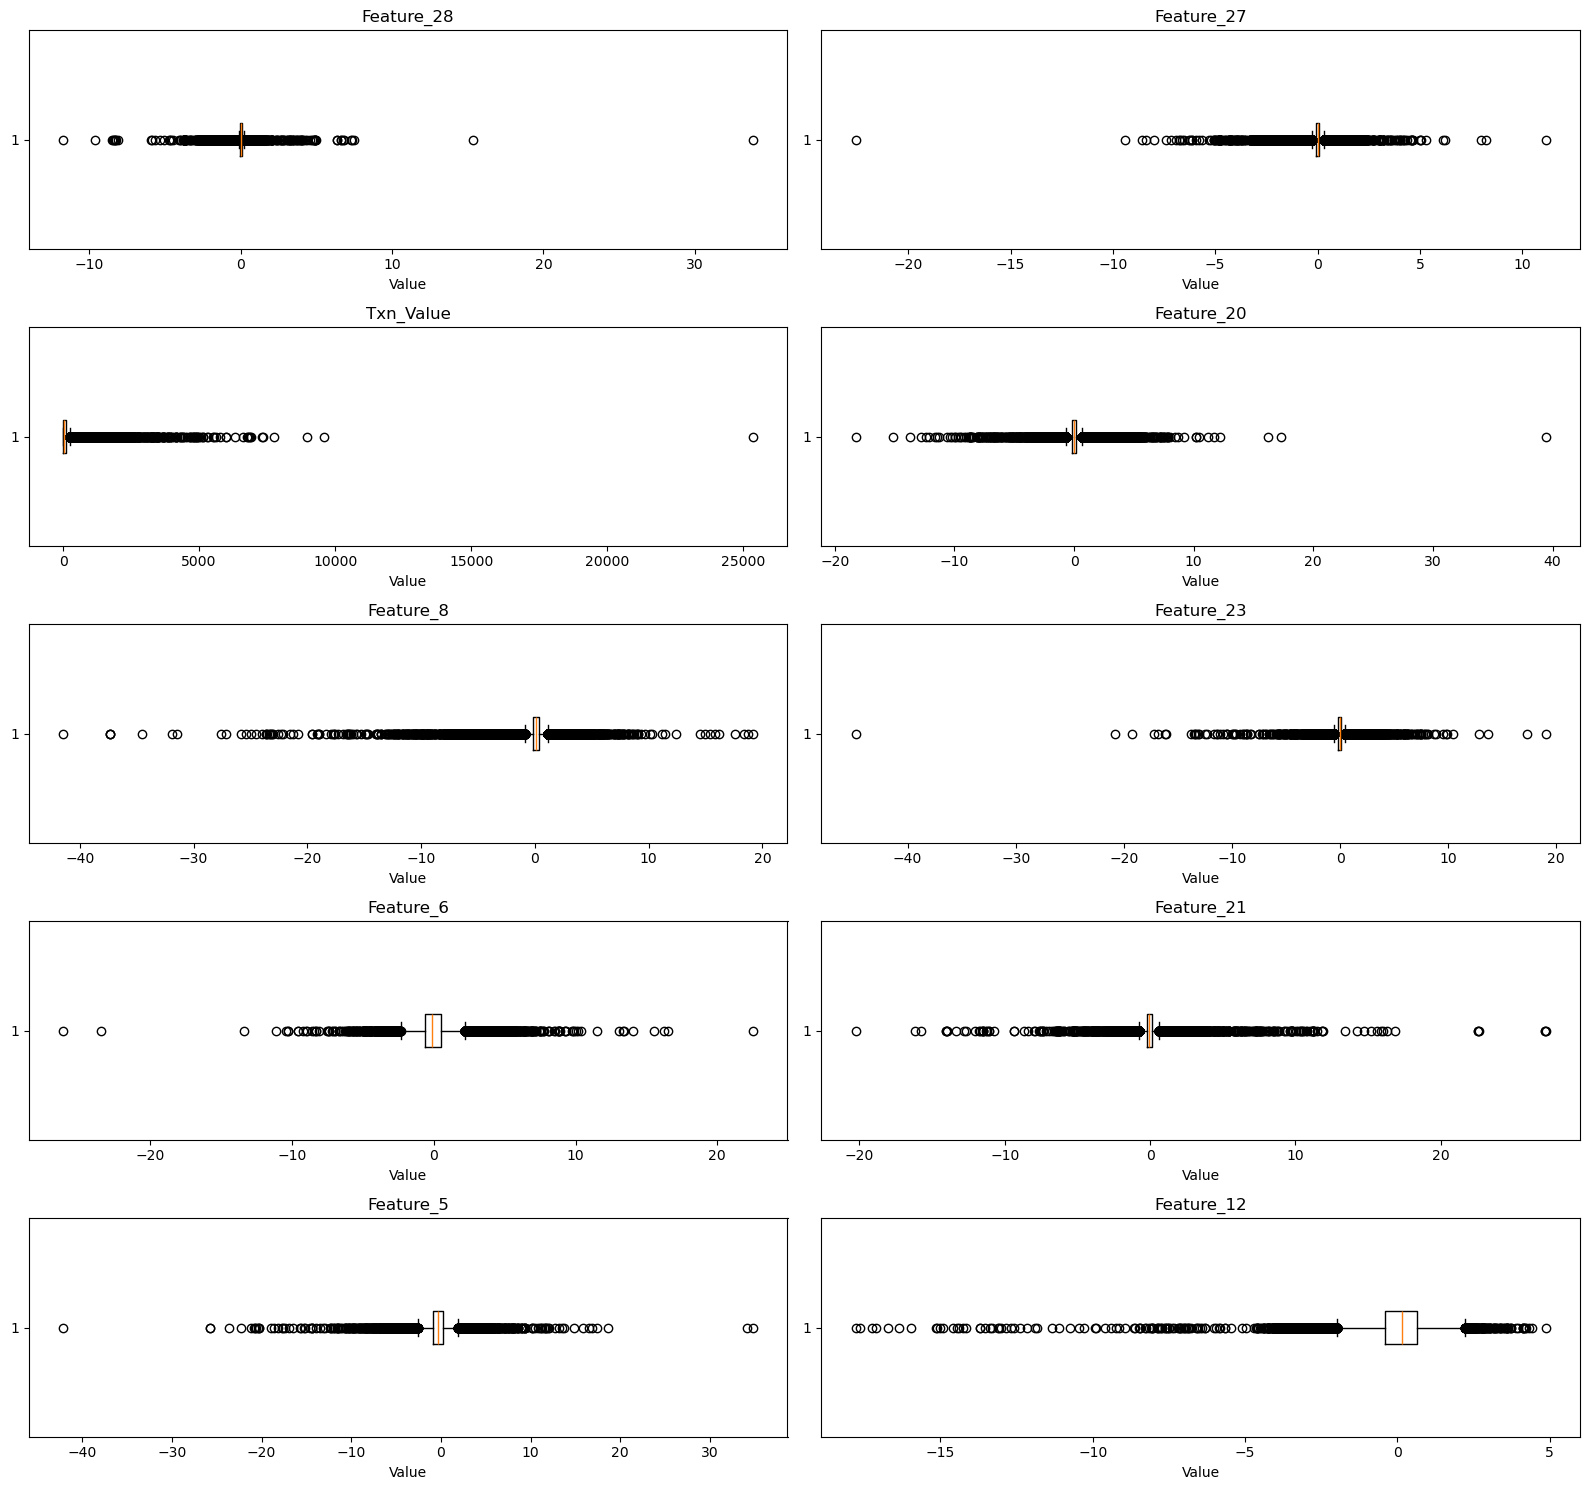

In [52]:
top_outlier_features = (
    outlier_df
    .head(10)["Feature"]
    .tolist()
)

number_of_columns = 2
number_of_rows = int(
    np.ceil(
        len(top_outlier_features) /
        number_of_columns
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(16, number_of_rows * 3)
)

axes = axes.flatten()

for index, column in enumerate(top_outlier_features):

    axes[index].boxplot(
        df[column].dropna(),
        vert=False
    )

    axes[index].set_title(column)
    axes[index].set_xlabel("Value")

for index in range(
    len(top_outlier_features),
    len(axes)
):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

In [53]:
class_comparison = []

normal_data = df[df["Risk_Flag"] == 0]
risk_data = df[df["Risk_Flag"] == 1]

for column in feature_columns:

    normal_mean = normal_data[column].mean()
    risk_mean = risk_data[column].mean()

    normal_median = normal_data[column].median()
    risk_median = risk_data[column].median()

    mean_difference = risk_mean - normal_mean

    class_comparison.append({
        "Feature": column,
        "Normal_Mean": normal_mean,
        "Risk_Mean": risk_mean,
        "Mean_Difference": mean_difference,
        "Absolute_Mean_Difference": abs(mean_difference),
        "Normal_Median": normal_median,
        "Risk_Median": risk_median,
        "Median_Difference": risk_median - normal_median
    })

class_comparison_df = pd.DataFrame(
    class_comparison
)

class_comparison_df = class_comparison_df.sort_values(
    by="Absolute_Mean_Difference",
    ascending=False
)

display(class_comparison_df)

,Feature,Normal_Mean,Risk_Mean,Mean_Difference,Absolute_Mean_Difference,Normal_Median,Risk_Median,Median_Difference
16,Feature_17,0.0648,-7.7684,-7.8332,7.8332,-0.0127,-6.1224,-6.1097
2,Feature_3,0.6891,-6.9216,-7.6107,7.6107,0.7494,-5.0337,-5.7831
13,Feature_14,0.0485,-7.5077,-7.5562,7.5562,0.0612,-7.1349,-7.1962
11,Feature_12,0.0105,-6.7595,-6.7701,6.7701,0.1522,-6.8490,-7.0011
9,Feature_10,-0.0016,-5.8511,-5.8495,5.8495,-0.0910,-5.1047,-5.0137
6,Feature_7,-0.1063,-5.8927,-5.7865,5.7865,-0.0675,-3.9661,-3.8986
0,Feature_1,-0.2346,-5.2490,-5.0144,5.0144,-0.2504,-2.7457,-2.4952
15,Feature_16,0.0066,-4.7441,-4.7506,4.7506,0.0760,-4.1836,-4.2596
3,Feature_4,0.1385,4.4571,4.3187,4.3187,0.1720,4.2544,4.0824
1,Feature_2,-0.0057,4.0524,4.0581,4.0581,0.0892,3.0309,2.9417


In [54]:
smd_report = []

for column in feature_columns:

    normal_values = normal_data[column].dropna()
    risk_values = risk_data[column].dropna()

    normal_mean = normal_values.mean()
    risk_mean = risk_values.mean()

    normal_std = normal_values.std()
    risk_std = risk_values.std()

    pooled_std = np.sqrt(
        (
            ((len(normal_values) - 1) * normal_std ** 2) +
            ((len(risk_values) - 1) * risk_std ** 2)
        ) /
        (
            len(normal_values) +
            len(risk_values) -
            2
        )
    )

    if pooled_std == 0:
        standardized_difference = 0
    else:
        standardized_difference = (
            risk_mean - normal_mean
        ) / pooled_std

    smd_report.append({
        "Feature": column,
        "Normal_Mean": normal_mean,
        "Risk_Mean": risk_mean,
        "Standardized_Mean_Difference":
            standardized_difference,
        "Absolute_SMD":
            abs(standardized_difference)
    })

smd_df = pd.DataFrame(smd_report)

smd_df = smd_df.sort_values(
    by="Absolute_SMD",
    ascending=False
)

display(smd_df)

,Feature,Normal_Mean,Risk_Mean,Standardized_Mean_Difference,Absolute_SMD
16,Feature_17,0.0648,-7.7684,-9.3314,9.3314
13,Feature_14,0.0485,-7.5077,-8.5464,8.5464
11,Feature_12,0.0105,-6.7595,-6.7137,6.7137
2,Feature_3,0.6891,-6.9216,-6.2502,6.2502
9,Feature_10,-0.0016,-5.8511,-5.6927,5.6927
15,Feature_16,0.0066,-4.7441,-5.5180,5.5180
6,Feature_7,-0.1063,-5.8927,-5.0792,5.0792
10,Feature_11,0.2162,4.1370,3.7772,3.7772
17,Feature_18,-0.0874,-2.8146,-3.2845,3.2845
3,Feature_4,0.1385,4.4571,3.2713,3.2713


In [55]:
risk_correlation = (
    df[feature_columns + ["Risk_Flag"]]
    .corr()["Risk_Flag"]
    .drop("Risk_Flag")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

risk_correlation_df = pd.DataFrame({
    "Feature": risk_correlation.index,
    "Correlation_with_Risk": risk_correlation.values,
    "Absolute_Correlation": abs(
        risk_correlation.values
    )
})

display(risk_correlation_df)

,Feature,Correlation_with_Risk,Absolute_Correlation
0,Feature_17,-0.3892,0.3892
1,Feature_14,-0.3609,0.3609
2,Feature_12,-0.2908,0.2908
3,Feature_3,-0.2723,0.2723
4,Feature_10,-0.2496,0.2496
5,Feature_16,-0.2424,0.2424
6,Feature_7,-0.2241,0.2241
7,Feature_11,0.1686,0.1686
8,Feature_18,-0.1471,0.1471
9,Feature_4,0.1465,0.1465


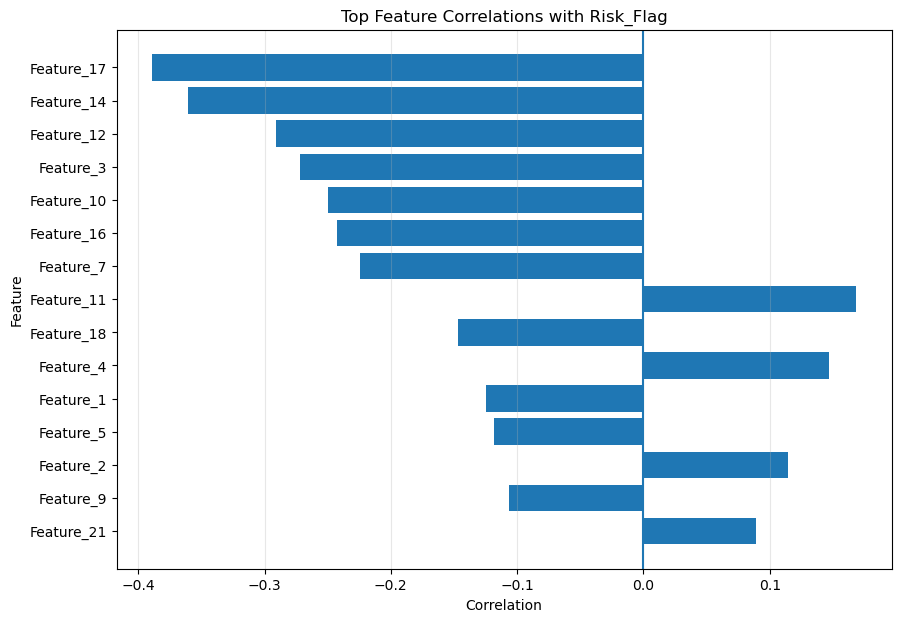

In [56]:
top_risk_features = risk_correlation_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_risk_features["Feature"][::-1],
    top_risk_features[
        "Correlation_with_Risk"
    ][::-1]
)

plt.title("Top Feature Correlations with Risk_Flag")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.axvline(0)
plt.grid(axis="x", alpha=0.3)
plt.show()

In [57]:
auc_report = []

y = df["Risk_Flag"]

for column in feature_columns:

    feature_values = df[column]

    try:
        raw_auc = roc_auc_score(
            y,
            feature_values
        )

        auc_strength = max(
            raw_auc,
            1 - raw_auc
        )

    except ValueError:
        raw_auc = np.nan
        auc_strength = np.nan

    auc_report.append({
        "Feature": column,
        "Raw_AUC": raw_auc,
        "AUC_Strength": auc_strength
    })

auc_df = pd.DataFrame(auc_report)

auc_df = auc_df.sort_values(
    by="AUC_Strength",
    ascending=False
)

display(auc_df)

,Feature,Raw_AUC,AUC_Strength
13,Feature_14,0.0281,0.9719
11,Feature_12,0.0477,0.9523
2,Feature_3,0.0540,0.9460
9,Feature_10,0.0573,0.9427
3,Feature_4,0.9352,0.9352
10,Feature_11,0.9164,0.9164
1,Feature_2,0.8996,0.8996
15,Feature_16,0.1170,0.8830
6,Feature_7,0.1421,0.8579
16,Feature_17,0.1525,0.8475


In [58]:
class_outlier_report = []

for column in feature_columns:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    outlier_mask = (
        (df[column] < lower_fence) |
        (df[column] > upper_fence)
    )

    normal_outlier_count = (
        outlier_mask &
        (df["Risk_Flag"] == 0)
    ).sum()

    risk_outlier_count = (
        outlier_mask &
        (df["Risk_Flag"] == 1)
    ).sum()

    normal_outlier_percentage = (
        normal_outlier_count /
        normal_count
    ) * 100

    risk_outlier_percentage = (
        risk_outlier_count /
        risk_count
    ) * 100

    class_outlier_report.append({
        "Feature": column,
        "Normal_Outlier_Count":
            normal_outlier_count,
        "Normal_Outlier_Percentage":
            normal_outlier_percentage,
        "Risk_Outlier_Count":
            risk_outlier_count,
        "Risk_Outlier_Percentage":
            risk_outlier_percentage
    })

class_outlier_df = pd.DataFrame(
    class_outlier_report
)

class_outlier_df = class_outlier_df.sort_values(
    by="Risk_Outlier_Percentage",
    ascending=False
)

display(class_outlier_df)

,Feature,Normal_Outlier_Count,Normal_Outlier_Percentage,Risk_Outlier_Count,Risk_Outlier_Percentage
13,Feature_14,3371,5.4628,114,89.7638
11,Feature_12,3431,5.5601,111,87.4016
16,Feature_17,1568,2.5410,110,86.6142
9,Feature_10,2282,3.6981,110,86.6142
15,Feature_16,1446,2.3433,99,77.9528
26,Feature_27,9097,14.7420,96,75.5906
2,Feature_3,1944,3.1503,95,74.8031
27,Feature_28,11267,18.2586,90,70.8661
6,Feature_7,2114,3.4258,83,65.3543
20,Feature_21,3888,6.3006,78,61.4173


In [59]:
correlation_matrix = df[
    feature_columns
].corr()

display(correlation_matrix)

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value
Feature_1,1.0000,0.0323,0.1918,-0.0491,0.0040,0.0463,0.0582,0.0026,-0.0684,-0.0188,0.0143,-0.0200,0.0027,0.0358,0.0468,0.0199,0.0206,-0.0090,-0.0036,-0.0037,-0.0239,-0.0556,-0.0687,-0.0173,0.2087,0.0165,0.0146,0.1025,-0.2403
Feature_2,0.0323,1.0000,-0.0796,0.0383,-0.0239,0.0063,-0.0119,0.0064,-0.0011,0.0160,0.0267,-0.0172,0.0377,-0.0013,0.0756,0.0265,-0.0546,-0.0105,0.0009,-0.0559,0.0071,-0.0325,0.0306,-0.0168,-0.0967,-0.0324,0.0192,-0.0410,-0.5426
Feature_3,0.1918,-0.0796,1.0000,-0.0699,0.1592,-0.0807,0.1659,-0.1111,0.1007,0.0803,-0.0647,0.0627,-0.0598,0.0454,-0.1945,-0.0747,0.0638,-0.0377,-0.0310,-0.0722,0.0259,0.2539,0.0404,0.0267,-0.1917,0.0372,-0.0553,0.0175,-0.2283
Feature_4,-0.0491,0.0383,-0.0699,1.0000,0.0091,-0.0378,-0.0033,0.0356,0.0489,-0.0889,0.0038,0.0374,-0.0117,-0.0091,-0.0311,-0.0802,0.0154,-0.0349,0.0198,0.0028,0.0192,0.0356,-0.0084,-0.0016,-0.0013,-0.0295,0.0329,0.0191,0.0909
Feature_5,0.0040,-0.0239,0.1592,0.0091,1.0000,0.0571,-0.0492,-0.0215,0.0293,0.0514,-0.0016,0.0117,0.0510,0.0204,0.1197,0.0995,-0.0655,0.0380,0.0190,-0.0385,-0.0576,-0.0901,0.0027,-0.0182,-0.0142,-0.0439,-0.0284,0.0250,-0.4030
Feature_6,0.0463,0.0063,-0.0807,-0.0378,0.0571,1.0000,0.0333,-0.0394,0.0425,-0.0163,-0.0950,0.0108,-0.0105,0.0234,-0.1238,-0.0197,0.0023,0.0457,0.0927,0.0458,0.0235,0.0367,-0.0067,-0.0060,0.0519,0.0028,-0.0062,-0.0365,0.2111
Feature_7,0.0582,-0.0119,0.1659,-0.0033,-0.0492,0.0333,1.0000,0.0207,0.0423,0.0574,0.0008,0.0538,0.0209,0.0083,0.0888,0.0615,0.0012,0.0347,-0.0366,0.0753,-0.0122,-0.0408,0.0795,-0.0037,-0.0961,-0.0361,-0.0967,-0.0739,0.3787
Feature_8,0.0026,0.0064,-0.1111,0.0356,-0.0215,-0.0394,0.0207,1.0000,-0.0201,-0.0417,-0.0116,-0.0325,-0.0050,-0.0076,-0.0467,-0.0322,-0.0093,-0.0035,0.0299,-0.0124,-0.0018,0.0436,-0.0156,0.0023,0.0106,0.0139,0.0213,0.0229,-0.0924
Feature_9,-0.0684,-0.0011,0.1007,0.0489,0.0293,0.0425,0.0423,-0.0201,1.0000,-0.0092,-0.0097,-0.0200,-0.0203,0.0173,-0.1181,-0.0543,0.0736,-0.0376,0.0096,0.0238,0.0058,0.0445,-0.0537,0.0137,0.1216,0.1079,-0.0558,-0.0346,-0.0192
Feature_10,-0.0188,0.0160,0.0803,-0.0889,0.0514,-0.0163,0.0574,-0.0417,-0.0092,1.0000,0.0257,0.0183,-0.0130,-0.0520,0.0533,0.0640,0.0804,0.0499,-0.0024,-0.0003,-0.0299,-0.0486,-0.0045,0.0037,0.0216,-0.0195,-0.0958,-0.0348,-0.1249


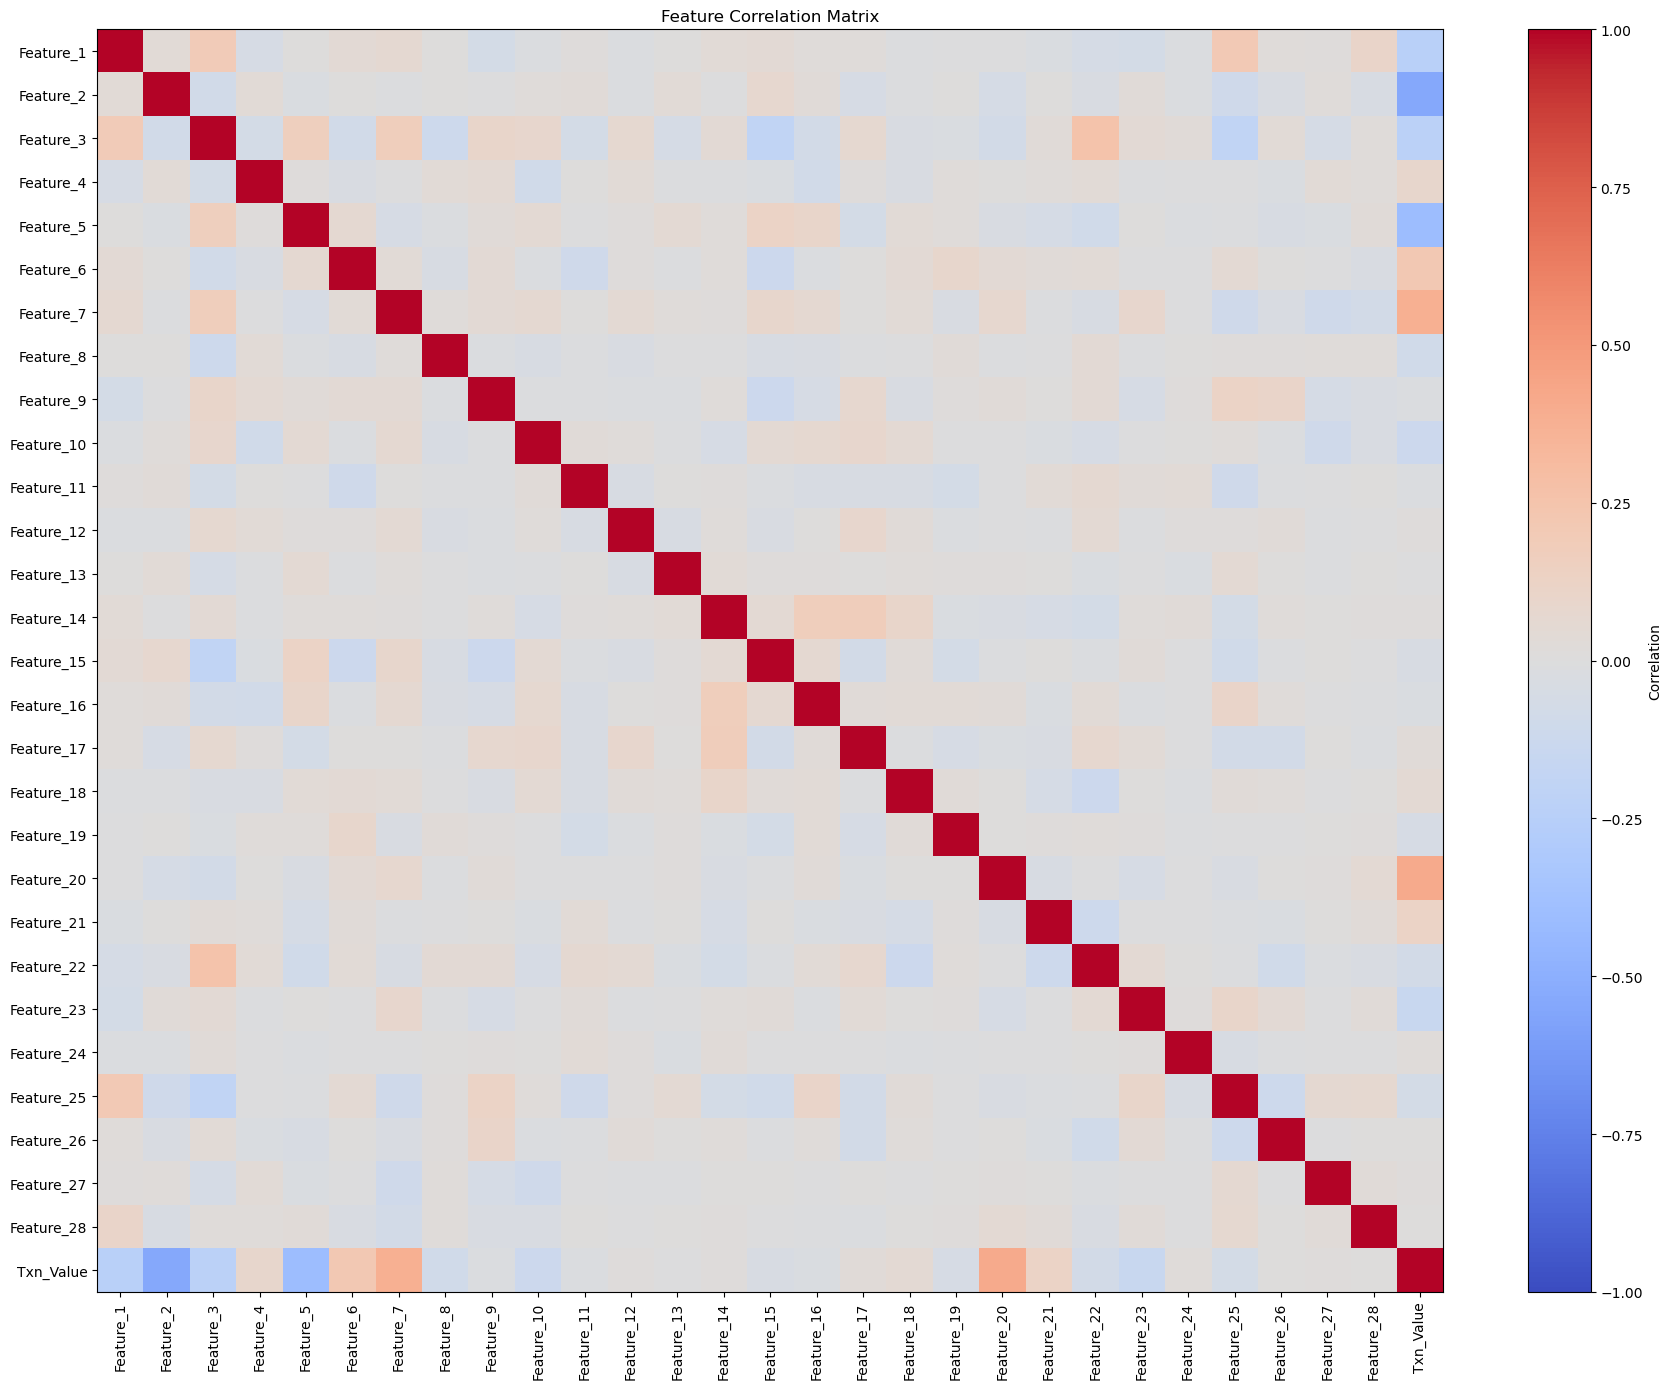

In [60]:
plt.figure(figsize=(18, 14))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [62]:
correlation_pairs = []

for first_index in range(
    len(feature_columns)
):

    for second_index in range(
        first_index + 1,
        len(feature_columns)
    ):

        first_feature = feature_columns[first_index]
        second_feature = feature_columns[second_index]

        correlation_value = correlation_matrix.loc[
            first_feature,
            second_feature
        ]

        correlation_pairs.append({
            "Feature_1": first_feature,
            "Feature_2": second_feature,
            "Correlation": correlation_value,
            "Absolute_Correlation":
                abs(correlation_value)
        })

correlation_pairs_df = pd.DataFrame(
    correlation_pairs
)

correlation_pairs_df = (
    correlation_pairs_df
    .sort_values(
        by="Absolute_Correlation",
        ascending=False
    )
)

display(correlation_pairs_df.head(30))

high_correlation_pairs = correlation_pairs_df[
    correlation_pairs_df[
        "Absolute_Correlation"
    ] >= 0.80
]

display(high_correlation_pairs)

print(
    "Feature pairs with correlation >= 0.80:",
    len(high_correlation_pairs)
)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
54,Feature_2,Txn_Value,-0.5426,0.5426
369,Feature_20,Txn_Value,0.4123,0.4123
129,Feature_5,Txn_Value,-0.4030,0.4030
174,Feature_7,Txn_Value,0.3787,0.3787
73,Feature_3,Feature_22,0.2539,0.2539
27,Feature_1,Txn_Value,-0.2403,0.2403
80,Feature_3,Txn_Value,-0.2283,0.2283
152,Feature_6,Txn_Value,0.2111,0.2111
23,Feature_1,Feature_25,0.2087,0.2087
66,Feature_3,Feature_15,-0.1945,0.1945


,Feature_1,Feature_2,Correlation,Absolute_Correlation


Feature pairs with correlation >= 0.80: 0


In [63]:
complete_feature_report = []

for column in feature_columns:

    column_data = df[column].dropna()

    q1 = column_data.quantile(0.25)
    q3 = column_data.quantile(0.75)

    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    outlier_mask = (
        (df[column] < lower_fence) |
        (df[column] > upper_fence)
    )

    feature_skewness = column_data.skew()

    complete_feature_report.append({
        "Feature": column,
        "Count": column_data.count(),
        "Missing": df[column].isnull().sum(),
        "Unique": column_data.nunique(),
        "Mean": column_data.mean(),
        "Std": column_data.std(),
        "Minimum": column_data.min(),
        "Q1": q1,
        "Median": column_data.median(),
        "Q3": q3,
        "Maximum": column_data.max(),
        "Skewness": feature_skewness,
        "Skew_Class":
            classify_skewness(feature_skewness),
        "Kurtosis": column_data.kurtosis(),
        "Lower_Fence": lower_fence,
        "Upper_Fence": upper_fence,
        "Outlier_Count": outlier_mask.sum(),
        "Outlier_Percentage":
            outlier_mask.mean() * 100,
        "Zero_Count":
            (column_data == 0).sum(),
        "Zero_Percentage":
            (column_data == 0).mean() * 100,
        "Negative_Count":
            (column_data < 0).sum(),
        "Positive_Count":
            (column_data > 0).sum(),
        "Correlation_with_Risk":
            df[column].corr(df["Risk_Flag"])
    })

complete_report_df = pd.DataFrame(
    complete_feature_report
)

complete_report_df = complete_report_df.sort_values(
    by="Outlier_Percentage",
    ascending=False
)

display(complete_report_df)

,Feature,Count,Missing,Unique,Mean,Std,Minimum,Q1,Median,Q3,Maximum,Skewness,Skew_Class,Kurtosis,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percentage,Zero_Count,Zero_Percentage,Negative_Count,Positive_Count,Correlation_with_Risk
27,Feature_28,61835,0,61835,0.0026,0.3393,-11.7159,-0.0048,0.0234,0.0764,33.8426,14.9451,Highly Skewed,"1,800.6260",-0.1265,0.1981,11357,18.3666,0,0.0000,16968,44867,0.0249
26,Feature_27,61835,0,61835,0.0000,0.4024,-22.5673,-0.0602,0.0110,0.0848,11.1348,-5.1569,Highly Skewed,236.5082,-0.2778,0.3024,9193,14.8670,0,0.0000,28366,33469,0.0556
28,Txn_Value,61835,0,19838,119.2565,320.9112,0.0000,8.6300,31.7200,106.9900,"25,361.2100",15.5128,Highly Skewed,726.8773,-138.9100,254.5300,6874,11.1167,3077,4.9761,0,58758,0.0001
19,Feature_20,61835,0,61835,0.0387,0.7267,-18.2667,-0.1698,-0.0268,0.1664,39.4108,2.2414,Highly Skewed,203.6502,-0.6741,0.6708,6334,10.2434,0,0.0000,33522,28313,0.0133
7,Feature_8,61835,0,61835,0.0555,1.2319,-41.4766,-0.1357,0.0771,0.3695,19.1655,-8.1065,Highly Skewed,174.8875,-0.8936,1.1274,5421,8.7669,0,0.0000,25234,36601,0.0524
22,Feature_23,61835,0,61835,-0.0355,0.6148,-44.8102,-0.1740,-0.0470,0.0818,18.9987,-9.0333,Highly Skewed,635.4495,-0.5577,0.4655,5061,8.1847,0,0.0000,37170,24665,-0.0099
5,Feature_6,61835,0,61835,0.0885,1.2887,-26.1600,-0.6559,-0.1648,0.4732,22.5170,1.2735,Highly Skewed,12.6327,-2.3495,2.1668,5017,8.1135,0,0.0000,35757,26078,-0.0610
20,Feature_21,61835,0,61835,-0.0343,0.7429,-20.2660,-0.2257,-0.0581,0.1170,27.2051,5.2457,Highly Skewed,236.9917,-0.7397,0.6310,3966,6.4138,0,0.0000,36781,25054,0.0890
4,Feature_5,61835,0,61835,-0.2843,1.3128,-42.1543,-0.9019,-0.3186,0.2378,34.8110,-0.9707,Moderately Skewed,63.8287,-2.6115,1.9475,3782,6.1163,0,0.0000,40375,21460,-0.1184
11,Feature_12,61835,0,61835,-0.0034,1.0539,-17.7854,-0.4047,0.1504,0.6438,4.8655,-2.5456,Highly Skewed,22.7389,-1.9776,2.2167,3542,5.7281,0,0.0000,26047,35788,-0.2908


In [64]:
print("=" * 80)
print("DATASET ANALYSIS SUMMARY")
print("=" * 80)

print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(
    f"Numeric columns: "
    f"{len(numeric_columns)}"
)
print(
    f"Non-numeric columns: "
    f"{len(non_numeric_columns)}"
)

print(
    f"\nTotal missing values: "
    f"{df.isnull().sum().sum():,}"
)

print(
    f"Duplicate rows: "
    f"{df.duplicated().sum():,}"
)

if "Txn_ID" in df.columns:

    print(
        f"Duplicate Txn_ID: "
        f"{df['Txn_ID'].duplicated().sum():,}"
    )

print("\nTarget distribution:")
print(target_report)

print(
    f"\nImbalance ratio: "
    f"{imbalance_ratio:.2f}:1"
)

print("\nSkewness category count:")
print(
    skewness_df[
        "Skew_Class"
    ].value_counts()
)

print("\nTop 10 outlier features:")
print(
    outlier_df[
        [
            "Feature",
            "Outlier_Count",
            "Outlier_Percentage"
        ]
    ].head(10)
)

print("\nTop features correlated with Risk_Flag:")
print(
    risk_correlation_df.head(10)
)

print("\nTop single-feature AUC:")
print(
    auc_df.head(10)
)

print("\nTop correlated feature pairs:")
print(
    correlation_pairs_df.head(10)
)

DATASET ANALYSIS SUMMARY
Total rows: 61,835
Total columns: 32
Numeric columns: 30
Non-numeric columns: 1

Total missing values: 0
Duplicate rows: 0
Duplicate Txn_ID: 0

Target distribution:
           Count  Percentage
Risk_Flag                   
0.0000     61708     99.7946
1.0000       127      0.2054

Imbalance ratio: 485.89:1

Skewness category count:
Skew_Class
Highly Skewed              16
Moderately Skewed           7
Approximately Symmetric     6
Name: count, dtype: int64

Top 10 outlier features:
       Feature  Outlier_Count  Outlier_Percentage
27  Feature_28          11357             18.3666
26  Feature_27           9193             14.8670
28   Txn_Value           6874             11.1167
19  Feature_20           6334             10.2434
7    Feature_8           5421              8.7669
22  Feature_23           5061              8.1847
5    Feature_6           5017              8.1135
20  Feature_21           3966              6.4138
4    Feature_5           3782         

In [65]:
output_file = "complete_dataset_analysis_report.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    df.head(1000).to_excel(
        writer,
        sheet_name="Sample_Data",
        index=False
    )

    missing_report.to_excel(
        writer,
        sheet_name="Missing_Report"
    )

    unique_report.to_excel(
        writer,
        sheet_name="Unique_Report",
        index=False
    )

    statistical_summary.to_excel(
        writer,
        sheet_name="Statistical_Summary"
    )

    skewness_df.to_excel(
        writer,
        sheet_name="Skewness_Report",
        index=False
    )

    outlier_df.to_excel(
        writer,
        sheet_name="Outlier_Report",
        index=False
    )

    target_report.to_excel(
        writer,
        sheet_name="Target_Report"
    )

    class_comparison_df.to_excel(
        writer,
        sheet_name="Class_Comparison",
        index=False
    )

    smd_df.to_excel(
        writer,
        sheet_name="SMD_Report",
        index=False
    )

    risk_correlation_df.to_excel(
        writer,
        sheet_name="Risk_Correlation",
        index=False
    )

    auc_df.to_excel(
        writer,
        sheet_name="Feature_AUC",
        index=False
    )

    class_outlier_df.to_excel(
        writer,
        sheet_name="Class_Outliers",
        index=False
    )

    correlation_pairs_df.to_excel(
        writer,
        sheet_name="Correlation_Pairs",
        index=False
    )

    complete_report_df.to_excel(
        writer,
        sheet_name="Complete_Report",
        index=False
    )

print(
    f"Analysis report saved successfully: "
    f"{output_file}"
)

Analysis report saved successfully: complete_dataset_analysis_report.xlsx


In [68]:
model_df = df.copy()

# remove Identifier 
model_df = model_df.drop(
    columns=["Txn_ID"],
    errors="ignore"
)

# Txn_Value log transformation
model_df["Txn_Value"] = np.log1p(
    model_df["Txn_Value"]
)

X = model_df.drop(
    columns=["Risk_Flag"]
)

y = model_df["Risk_Flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts())




from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target percentage:")
print(
    y_train.value_counts(
        normalize=True
    ) * 100
)

print("\nTesting target percentage:")
print(
    y_test.value_counts(
        normalize=True
    ) * 100
)


from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

X shape: (61835, 30)
y shape: (61835,)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Txn_Value_log
0,-2.1836,1.8928,-1.1427,-2.4361,1.3969,3.7179,-2.1230,-1.5435,-0.4812,-1.2273,-0.6396,0.4177,-0.1851,1.0918,0.5124,1.3226,-0.6466,0.2248,-0.5394,0.5332,-0.5647,-0.4004,0.3502,0.9932,-0.1392,0.7368,0.1135,0.1488,0.4762,0.4762
1,-1.5469,1.8505,2.1769,3.0357,-1.1929,0.9558,-1.7587,-1.7980,-0.8295,0.0302,-1.4017,-0.6627,-1.5661,0.5526,0.5438,0.2020,0.6370,0.4295,0.8274,0.6960,-1.2864,0.3513,0.0088,0.3204,-0.0748,0.2323,0.0720,0.1345,0.0000,0.0000
2,-1.5227,1.0816,0.1821,0.9902,1.5867,4.4743,-0.9494,1.7100,-0.4479,0.3309,-1.0515,-0.0939,0.0288,-0.1246,-0.3177,1.0037,-0.7182,0.4251,-0.3074,-0.3149,-0.0124,-0.2115,0.0742,0.9865,0.0147,-0.1347,-0.8394,-0.3185,3.6389,3.6389
3,-0.6641,0.4260,2.6913,-1.7009,-0.3761,-0.6739,0.4376,-0.2474,2.5628,-2.0377,0.3758,-2.1475,1.5309,0.9165,-0.0349,-0.3983,0.2574,0.5183,-0.1473,-0.0586,-0.1504,0.0980,-0.3691,0.3365,0.4716,-0.8408,-0.0927,-0.1544,2.7428,2.7428
4,-0.6188,0.6014,1.6764,-0.8583,-0.2046,-0.4588,0.9588,-0.4066,-1.3802,0.4269,-0.1291,0.0680,0.6440,-0.2802,0.1993,-1.5957,-0.3150,0.4182,-2.3621,-0.6015,-0.3975,-0.5935,0.0385,0.3214,-0.4583,-0.8610,-0.2385,-0.0832,4.1937,4.1937


Risk_Flag
0.0000    61708
1.0000      127
Name: count, dtype: int64

Training shape: (49468, 30)
Testing shape: (12367, 30)

Training target percentage:
Risk_Flag
0.0000   99.7938
1.0000    0.2062
Name: proportion, dtype: float64

Testing target percentage:
Risk_Flag
0.0000   99.7978
1.0000    0.2022
Name: proportion, dtype: float64


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Txn_Value_log
59871,0.2498,1.2598,-2.4964,0.6571,1.4810,-1.1007,1.2886,-1.2625,0.7981,0.3168,-0.1195,-1.9867,-1.2358,-4.8969,0.9168,0.8546,2.7977,2.0713,-0.1453,1.6486,-1.0628,-0.4394,0.1051,-1.2565,-0.8143,-0.5220,1.5250,-2.9429,-0.0865,-0.0865
1795,0.7657,-0.4536,-0.7849,-0.6008,-0.3434,-0.6762,-0.2941,-0.2325,-0.6762,1.0757,0.3968,-1.4664,-1.9388,0.9445,-0.2136,1.1771,0.2193,-0.9391,1.2637,-0.2216,-0.2685,-0.7164,0.3836,-0.2123,0.3818,-0.5999,-0.4121,-0.4323,-0.2592,-0.2592
3079,-0.1974,0.3706,-0.7405,-0.2348,2.6458,3.4361,0.7897,0.2771,-0.0320,0.9089,-0.1674,-0.6681,-0.0273,-0.2574,0.8498,-0.1471,-1.1481,0.6816,0.7619,0.3485,0.3288,0.5629,-0.5084,1.2950,-0.6221,-0.5060,-4.8562,-2.3993,0.3824,0.3824
13775,-0.0288,0.7339,0.4580,-0.0697,0.2478,-0.7430,0.7226,-0.2326,-0.1201,-0.4202,-0.2985,-0.5709,-0.4174,-0.4186,0.5394,0.3302,0.0473,0.0453,-0.0635,0.2550,-0.6310,-0.7671,0.1587,0.3284,-0.6377,0.2065,1.6046,0.8871,-0.8759,-0.8759
47277,-0.2867,-0.4454,-0.0438,-0.6898,1.3833,-0.1442,-0.3348,-0.2792,-1.2102,0.8601,-0.0365,-0.0485,1.0499,-0.5406,-0.9046,0.6136,0.0901,-0.5863,2.5379,0.4984,0.7515,0.9671,-2.2518,-1.3269,0.0533,0.1343,0.8900,0.2460,-0.3986,-0.3986
